In [6]:
# First install the following packages:

# pip install openweathermap
# pip install openmeteo_requests
# pip install requests_cache
# pip install retry_requests

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
import pandas as pd 
from click.testing import CliRunner
from openweathermap import get_df
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import f_oneway

db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

# Loading data

## Electricity usage

In [194]:
# Getting electricity data
db.erase_table_content("P1e")
files = check_filepaths("P1e-*.csv.gz","P1e") + check_filepaths("P1e-*.csv","P1e")
for file in files:
    db.insert_table_P1e(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1e deleted successfully


## Gas usage

In [195]:
# Getting gas data
db.erase_table_content("P1g")
files = check_filepaths("P1g-*.csv.gz","P1g") + check_filepaths("P1g-*.csv","P1g")
for file in files:
    db.insert_table_P1g(file)

Are you sure you want to erase all contents of this table from the database? Y/N
Data in table P1g deleted successfully
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-01-01-2022-07-10.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-01-01-2022-09-22.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-04-01-2022-05-01.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-09-01-2022-10-07.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-09-01-2022-10-16.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_07\data\P1g\P1g-2022-09-01-2022-10-19.csv.gz successfully inserted into table P1g in database
C:\Users\eva\Documents\Statistics\EDS\GA2025_0

## Weather data

To get the openweather data, run the code below and type the right user input:
- Parameters: temp_real, rain, cloud_cover, sunshine, wind_speed
- New dataframe: Y

In [ ]:
# Getting openweather data in a roundabout way

runner = CliRunner()
cli_args=['2022-03-18','2025-03-28','--parameters','--newdf']

parameters='temp_real, rain, cloud_cover, sunshine, wind_speed'
result=runner.invoke(get_df, cli_args, input=parameters)


In [8]:
# splitting time and dates
weather = pd.read_csv('data/openweathermap/weather.csv')
weather[['date','time']]=weather['date'].str.split(' ', expand=True)
weather.head()

,date,temperature_2m,rain,cloud_cover,sunshine_duration,wind_speed_10m,time
0,2022-03-18,7.0085,0.0,98.0,0.0,13.905509,00:00:00+00:00
1,2022-03-18,6.7585,0.0,100.0,0.0,14.058450,01:00:00+00:00
2,2022-03-18,6.8585,0.0,100.0,0.0,15.188415,02:00:00+00:00
3,2022-03-18,6.8085,0.0,100.0,0.0,14.404499,03:00:00+00:00
4,2022-03-18,6.3585,0.0,89.0,0.0,12.979984,04:00:00+00:00


## Data preperation and merging

In [9]:
# turn into dataframe
p1e = db.return_whole_table("P1e")
p1g = db.return_whole_table("P1g")

In [10]:
# making sure the dates behave well
p1e["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1e["year"] = p1e["date"].dt.year
p1e["month"] = p1e["date"].dt.month
p1e["day_as_date"]=p1e["date"].dt.date
p1e["elec_usage"] = (p1e["Electricity_imported_T1"].diff() + p1e["Electricity_imported_T2"].diff()).fillna(0)

p1g["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1g["year"] = p1g["date"].dt.year
p1g["month"] = p1g["date"].dt.month
p1g["day_as_date"]=p1g["date"].dt.date
p1g["gas_usage"] = (p1g["Total_gas_used"].diff()).fillna(0)

p1e_new = p1e.groupby(by=["day_as_date","year","month"], as_index = False)["elec_usage"].aggregate(total_usage_electricity = "sum")
p1g_new = p1g.groupby(by=["day_as_date","year","month"], as_index = False)["gas_usage"].aggregate(total_usage_gas = "sum")

# merging dataframes
df = p1e_new.merge(p1g_new, how = "outer", on = ["day_as_date", "year", "month"])

In [11]:
df.head()

,day_as_date,year,month,total_usage_electricity,total_usage_gas
0,2022-03-18,2022,3,7.015,1.377
1,2022-03-19,2022,3,12.783,4.094
2,2022-03-20,2022,3,13.625,4.078
3,2022-03-21,2022,3,7.939,3.785
4,2022-03-22,2022,3,8.241,3.129


In [12]:
# making sure colnames are the same
df = df.rename(columns={'day_as_date':'date'})

In [13]:
# date col as the same vartype
df['date']=df['date'].astype(str)
weather['date']=weather['date'].astype(str)


In [14]:
# df with averages
#weather['date'] = pd.to_datetime(weather['date'], format='%Y-%m-%d')
weather_av=weather.groupby('date').agg(avg_sunshine=('sunshine_duration','mean'), # getting the means
                                        avg_windspeed=('wind_speed_10m','mean'),
                                        avg_cloudcover=('cloud_cover','mean'),
                                        avg_rain=('rain','mean'),
                                        avg_temp=('temperature_2m','mean'))
# getting the right coltype for dates
weather_av['date']=weather_av.index
weather_av.reset_index(drop=True,inplace=True)
weather_av['date']=weather_av['date'].astype(str)


In [15]:
# merging the data
weather_av_merge= pd.merge(df,weather_av,on='date')
weather_melt = weather_av_merge.melt(['date','year','month','total_usage_electricity','total_usage_gas'], var_name='weather_condition', value_name='value')
weather_melt.head()

,date,year,month,total_usage_electricity,total_usage_gas,weather_condition,value
0,2022-03-18,2022,3,7.015,1.377,avg_sunshine,1607.184558
1,2022-03-19,2022,3,12.783,4.094,avg_sunshine,1627.058578
2,2022-03-20,2022,3,13.625,4.078,avg_sunshine,1640.335150
3,2022-03-21,2022,3,7.939,3.785,avg_sunshine,1659.083092
4,2022-03-22,2022,3,8.241,3.129,avg_sunshine,1675.010350


# Analysis

In this report we are interested in a possible relation between weather conditions and the usage of electricity and gas. In the exploratory report we saw that the use of gas and electricity fluctuates during the different seasons. 

This lead us to the question:

##  Which factors that change during seasons would have the most influence on gas and electricity usage?

### Initial visualization

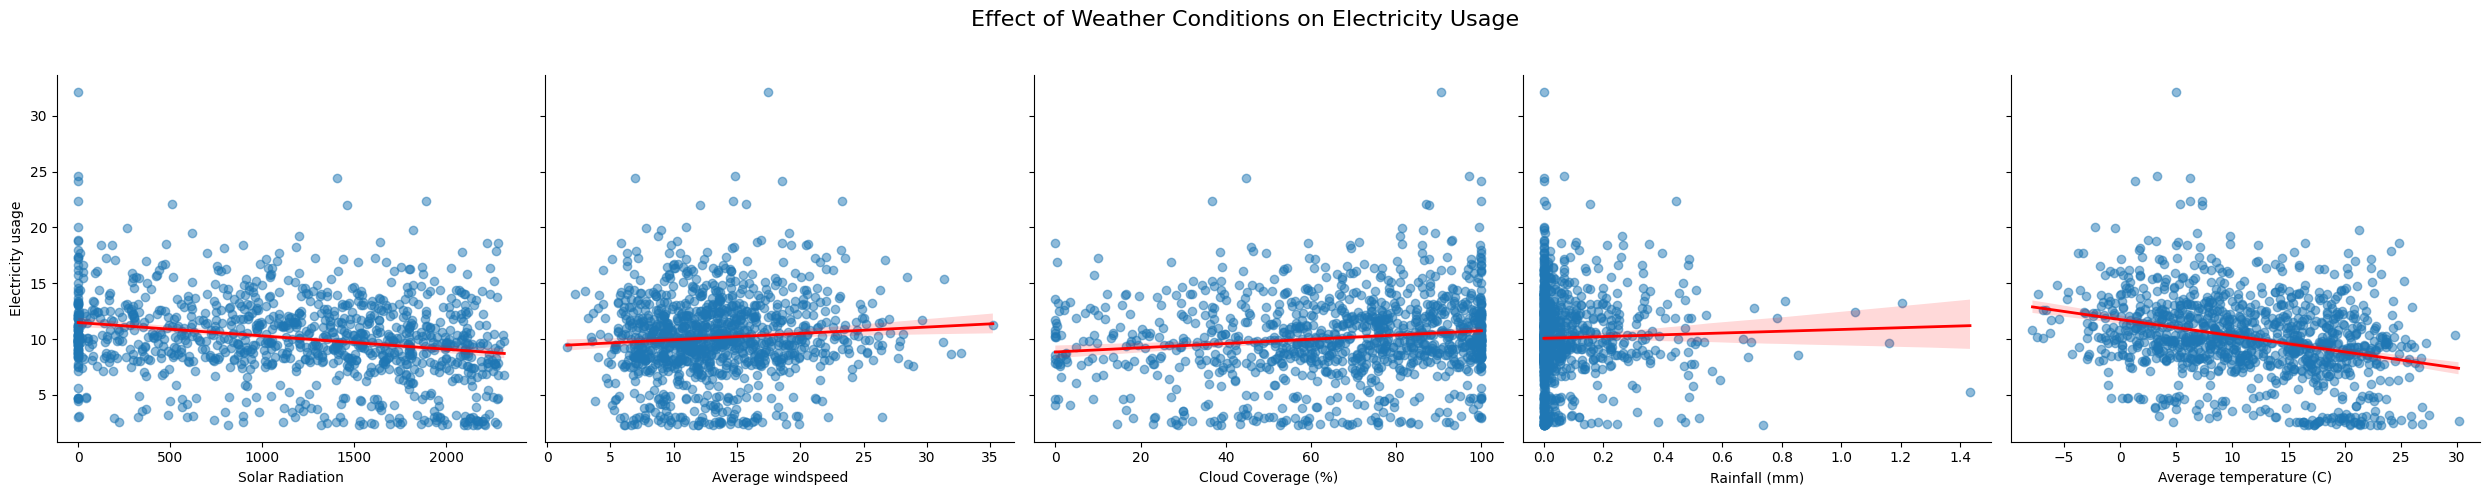

In [208]:
# facet grid
g = sns.FacetGrid(weather_melt, col='weather_condition', height=5, sharex=False)

# mapping the regression plots
g.map(sns.regplot, 'value', 'total_usage_electricity', scatter=True,line_kws={'color': 'red', 'linewidth': 2}, scatter_kws={'alpha':0.5})

# axis labels
g.set_ylabels('Electricity usage')
xlabels= {
    'avg_sunshine': 'Solar Radiation',
    'avg_windspeed': 'Average windspeed',
    'avg_cloudcover': 'Cloud Coverage (%)',
    'avg_rain': 'Rainfall (mm)',
    'avg_temp' : 'Average temperature (C)'}
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_xlabel(xlabels.get(title, 'value'))  
    
# main title
g.set_titles("") # removing subtitles
plt.subplots_adjust(top=0.85) 
g.fig.suptitle('Effect of Weather Conditions on Electricity Usage', fontsize=16)
plt.show()

In the plots above the electricity usage is displayed on the y-axis and the weather variables on the x-axis. We can see that the regression lines are close to horizontal with a slight slope. The average temperature seems to have the largest relation with electricity usage. 

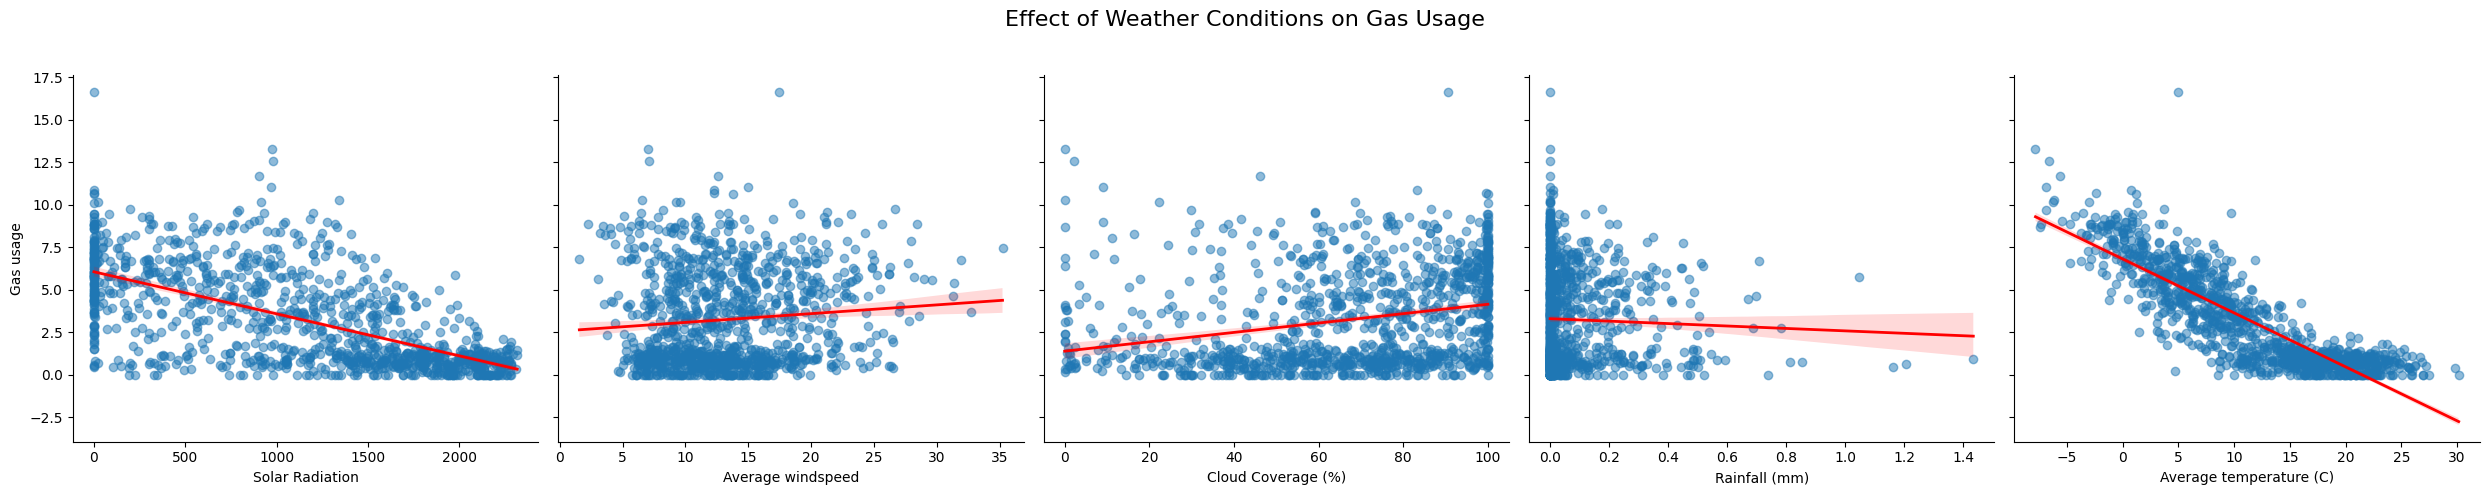

In [ ]:
# facet grid
g = sns.FacetGrid(weather_melt, col='weather_condition', height=5, sharex=False)

# mapping the regression plots
g.map(sns.regplot, 'value', 'total_usage_gas', scatter=True,line_kws={'color': 'red', 'linewidth': 2}, scatter_kws={'alpha':0.5})

# axis labels
g.set_ylabels('Gas usage')
xlabels= {
    'avg_sunshine': 'Solar Radiation',
    'avg_windspeed': 'Average windspeed',
    'avg_cloudcover': 'Cloud Coverage (%)',
    'avg_rain': 'Rainfall (mm)',
    'avg_temp' : 'Average temperature (C)'}
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_xlabel(xlabels.get(title, 'value'))
## COMMENT: SET Y_LABEL TO START AT 0

# main title
g.set_titles("") # removing subtitles
plt.subplots_adjust(top=0.85) 
g.fig.suptitle('Effect of Weather Conditions on Gas Usage', fontsize=16)
plt.show()

In the plot above, the y-axis indicates gas usage and the x-axis displays the different weather conditions. We can see that these relations behave similarly to those with electricity usage, but the relations with gas usage seem to have higher correlation. Especially the average temperature per day has a clear negative relationship with gas usage. The solar radiation also has a strong negative relationship with gas usage, although not as strong as average temperature. 

## Testing the Relations
To check whether the relations of the weather variables with gas and electricity usage are significant, we run a regression. After that we analyse whether different weather variables explain different levels of electricity and gas usage, respectively. 

### Regression
We run a multiple linear regression to look at the effect of each weather variable on electricity and gas usage while controlling for the other variables. 

In [16]:
weather_melt.head()

,date,year,month,total_usage_electricity,total_usage_gas,weather_condition,value
0,2022-03-18,2022,3,7.015,1.377,avg_sunshine,1607.184558
1,2022-03-19,2022,3,12.783,4.094,avg_sunshine,1627.058578
2,2022-03-20,2022,3,13.625,4.078,avg_sunshine,1640.335150
3,2022-03-21,2022,3,7.939,3.785,avg_sunshine,1659.083092
4,2022-03-22,2022,3,8.241,3.129,avg_sunshine,1675.010350


In [17]:
# multiple lin regression elect
model_elect = smf.ols('total_usage_electricity ~ avg_sunshine + avg_windspeed + avg_temp + avg_cloudcover + avg_rain', data=weather_av_merge).fit()
print(model_elect.summary())

                               OLS Regression Results                              
Dep. Variable:     total_usage_electricity   R-squared:                       0.098
Model:                                 OLS   Adj. R-squared:                  0.094
Method:                      Least Squares   F-statistic:                     23.92
Date:                     Sun, 25 May 2025   Prob (F-statistic):           6.88e-23
Time:                             12:29:23   Log-Likelihood:                -2961.2
No. Observations:                     1106   AIC:                             5934.
Df Residuals:                         1100   BIC:                             5964.
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

From the summary of the regression model, we can read the $p$-values from individual $t$-tests. We can read that the weather variables average temperature is the only variable to have a significant relationship with electricity usage when we control for the other variables. If we look at the $F$-statistic, we can see that model is significant overall.

As we can see from the coefficient value, average temperature has a somewhat strong negative relationship with average electricity usage.

In [20]:
# multiple lin regression gas
model_gas = smf.ols('total_usage_gas ~ avg_sunshine + avg_windspeed + avg_temp + avg_cloudcover + avg_rain', data=weather_av_merge).fit()
print(model_gas.summary())

                            OLS Regression Results                            
Dep. Variable:        total_usage_gas   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     665.6
Date:                Sun, 25 May 2025   Prob (F-statistic):               0.00
Time:                        12:31:31   Log-Likelihood:                -1948.0
No. Observations:                1106   AIC:                             3908.
Df Residuals:                    1100   BIC:                             3938.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.7743      0.247     27.

From the summary of the regression model, we can read the $p$-values from individual $t$-tests. We can read that the weather variables average sunshine, wind speed and temperature have a statistically significant relationship with gas usage. However, the average cloud cover and rain do not. The $F$-statistic also indicates that the model is significant overall. 

Looking at the coefficients of these statistically significant relationships, we see that average windspeed has a small positive relationship with gas usage; average temperature has a relatively large negative relationship with gas usage and average sunshine has a very small negative relationship with gas usage.